In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

#### experiments with derivatives
Derivative defines, how a function changes if we add a small change to the input point(x in this case), whether the value of the function goes up or down and by how much it changes.

In [2]:
# random function
def f(x):
    out = 3 * x**2 + 4*x + 2
    return out

In [3]:
f(5) #sample output

97

In [4]:
xs = np.arange(-5,5, 0.25)
ys = f(xs)
ys # sample output values from the function

array([57.    , 50.6875, 44.75  , 39.1875, 34.    , 29.1875, 24.75  ,
       20.6875, 17.    , 13.6875, 10.75  ,  8.1875,  6.    ,  4.1875,
        2.75  ,  1.6875,  1.    ,  0.6875,  0.75  ,  1.1875,  2.    ,
        3.1875,  4.75  ,  6.6875,  9.    , 11.6875, 14.75  , 18.1875,
       22.    , 26.1875, 30.75  , 35.6875, 41.    , 46.6875, 52.75  ,
       59.1875, 66.    , 73.1875, 80.75  , 88.6875])

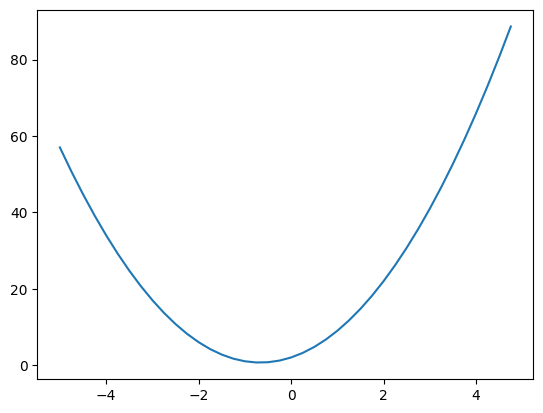

In [5]:
# plot the function
plt.plot(xs,ys)

In [6]:
h = 0.000000000000001 # the small change
x = -5
dydx = (f(x + h) - f(x)) / h
dydx

-28.421709430404004

Partial Derivatives

#### Creating the Value Class

In [7]:
class Value:
    def __init__(self, data, _children = (), _op='', label=''):
        self.data = data
        self.grad = 0 
        self._backward = lambda: None
        self._prev = set(_children) # keeps track of the value objects that led to the new value object
        self._op = _op  # keeps track of the operator that led to the value object
        self.label = label 
        
    def __repr__(self):
        return f"ValueData=({self.data}, label=({self.label}), gradient = ({self.grad}), backprop = ({self._backward}))"

    def __neg__(self):
        return self * -1

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out
        
    def __radd__(self, other):
        return self + other   

    def __sub__(self, other):
        return self + (-other)
        
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        
        def _backward():
            self.grad += out.grad * other.data
            other.grad += out.grad * self.data
        out._backward = _backward
        return out
        
    def __rmul__(self, other):
        return  self*other
      

    def __truediv__(self, other):
        return self * (other**-1)
        # a / b, a*(b**-1)
        # value(a) * (value(b) ** -1)
        
    def __pow__(self, other):
        assert isinstance(other, (int, float))
        out = Value(self.data**other, (self, ) , f'**{other}')

        def _backward():
            self.grad += (other * self.data**(other - 1)) * out.grad
        out._backward = _backward
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x),(self, ),'exp')

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out

    def tanh(self):
        n = self.data
        th = (math.exp(2*n) - 1)/(math.exp(2*n) + 1 )
        out = Value(th, (self, ), 'tanh')

        def _backward():
            self.grad = (1-th**2) * out.grad
        out._backward = _backward
        return out
        
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

#### Graphviz visualization

In [8]:
from graphviz import Digraph

In [9]:
def trace(root):
    # build the set of all the nodes and edges in a graph
    nodes , edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
            
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format = 'svg', graph_attr={'rankdir': 'LR'})

    nodes , edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph we create a rectangular node
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if the value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # connect the node to iit
            dot.edge(uid+n._op, uid)
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
        
    return dot

In [34]:
# these are two inputs x1, and x2 , we are creating a 2 dimensional nueron
x1 = Value(2.0, label ='x1')
x2 = Value(0.0, label = 'x2')

# weights w1 and w2
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')

# the bias of the neuron
b = Value(6.8813735870195432, label = 'b')
#x1w1 + x2w2 + b
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b ; n.label = 'n'

#we have to implement tanh
o = n.tanh() ; o.label = 'o' ; o.grad = 1.0
o.backward()

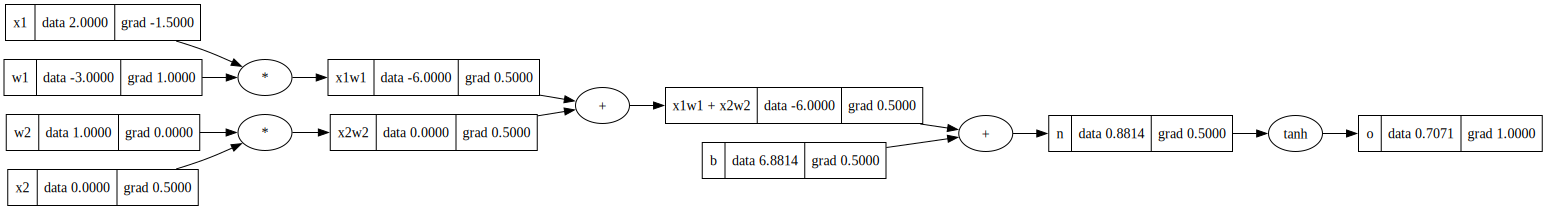

In [28]:
draw_dot(o)

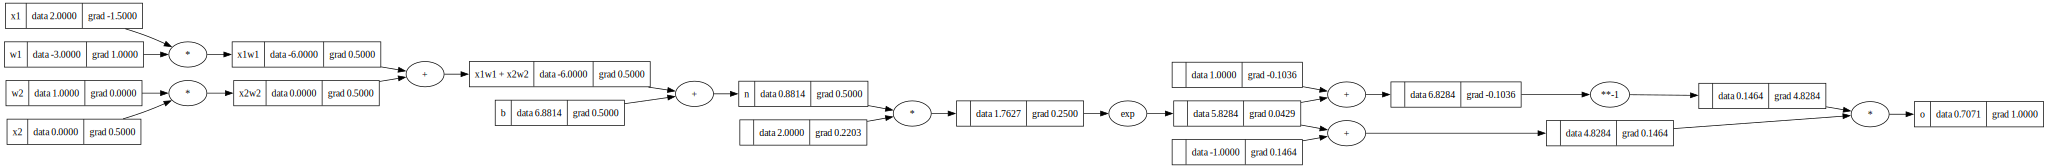

In [11]:
# these are two inputs x1, and x2 , we are creating a 2 dimensional nueron
x1 = Value(2.0, label ='x1')
x2 = Value(0.0, label = 'x2')

# weights w1 and w2
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')

# the bias of the neuron
b = Value(6.8813735870195432, label = 'b')
#x1w1 + x2w2 + b
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b ; n.label = 'n'
#tanh using a different formula
e = (2*n).exp()
o = (e - 1) / (e + 1)
#we have to implement tanh
o.label = 'o'
o.backward()
draw_dot(o)

In [19]:
# performing the same thing using pytorch api
import random

In [20]:
import torch

In [21]:
x1 = torch.Tensor([2.0]).double() ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double() ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double() ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double() ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double() ; b.requires_grad = True

n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

0.7071066904050358


In [47]:
#  creating a neuron
class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(1,-1)) for _ in range(nin)]
        self.b = Value(random.uniform(1, -1))

    def __call__(self, x):
        act = sum((xi*wi for xi, wi in zip(x,self.w)), self.b)
        out = act.tanh()
        return out

# creating a layer of neurons
class Layer:
    def __init__(self, nin, nouts):
        self.neurons = [Neuron(nin) for _ in range(nouts)]

    def __call__(self, x):
        outs  = [n(x) for n in self.neurons]
        return outs

# creating the MLP 
class MLP:
    def __init__(self, nin, nouts):
        szn = [nin] + [nouts] # [3,4,4,1]
        self.Layers = [Layer(szn[i], szn[i+1]) for i in range(len(szn)-1)]

    def __call__(self, x):
        for Layer in self.layers:
            x = Layer(x)
        return x
        

In [46]:
for i in range(4):
    print(i)

0
1
2
3
